<div align="center">



# **Análisis y Procesamiento de Señales**

## **Trabajo Semanal 4:  Primeras nociones de estimación espectral**



</div>

<br>
<br>
<br>
<br>

**Alumno:** Germán Fiore  
**Especialidad:** Ingeniería Biomédica  
**Fecha:** 20/09/2026  

---

### **Introducción:**

En el procesamiento digital de señales, el análisis espectral mediante la Transformada Discreta of Fourier (DFT) exige recortar un registro finito de $N$ muestras temporales. Esta operación equivale a multiplicar la señal continua o infinita por una ventana rectangular. Cuando la frecuencia de una componente senoidal no coincide exactamente con un centro de canal o bin de la DFT (es decir, cuando no entra un número entero exacto de ciclos en el registro de $N$ muestras), se produce una discontinuidad en los bordes de la repetición periódica implícita de la DFT. En el dominio frecuencial, este fenómeno se traduce en la convolución del espectro de la senoidal con el sinc periódico de la ventana, dando lugar al desparramo espectral (spectral leakage). La energía del tono original se disipa hacia los bins adyacentes a través de los lóbulos laterales, provocando atenuación en la lectura del pico y distorsionando la estimación de su amplitud y frecuencia. Para mitigar la fuga espectral se utilizan ventanas de ponderación suave $w[n]$. Sin embargo, existe un compromiso (trade-off): 
* Ventanas de lóbulos laterales muy bajos (como Blackman-Harris o Hann) reducen la fuga hacia frecuencias distantes pero ensanchan el lóbulo principal, perjudicando la resolución frecuencial.
* Ventanas de cumbre plana (Flat-top) sacrifican selectividad frecuencial para ofrecer una ganancia casi constante en la cima del lóbulo principal, eliminando la atenuación por desparramo y resultando óptimas para la medición precisa de amplitud (metrología).

### **Codigo completo:**


 RESULTADOS PARA SNR = 3 dB

Estimación de Amplitud (a_hat):
-----------------------------------------------------------------
Métrica    | Rectangular  | Flat-top     | Blackman-H.  | Hann        
-----------------------------------------------------------------
sa         |    -0.936982 |    -0.126396 |    -0.510242 |    -0.722920
va         | 1.865389e-01 | 2.735836e-02 | 1.301255e-01 | 2.227209e-01

Estimación de Frecuencia (Omega_hat):
-----------------------------------------------------------------
Métrica    | Rectangular  | Flat-top     | Blackman-H.  | Hann        
-----------------------------------------------------------------
sa         |    -0.000007 |     0.000319 |     0.000007 |     0.000001
va         | 5.472990e-05 | 6.277862e-05 | 5.417493e-05 | 5.454525e-05


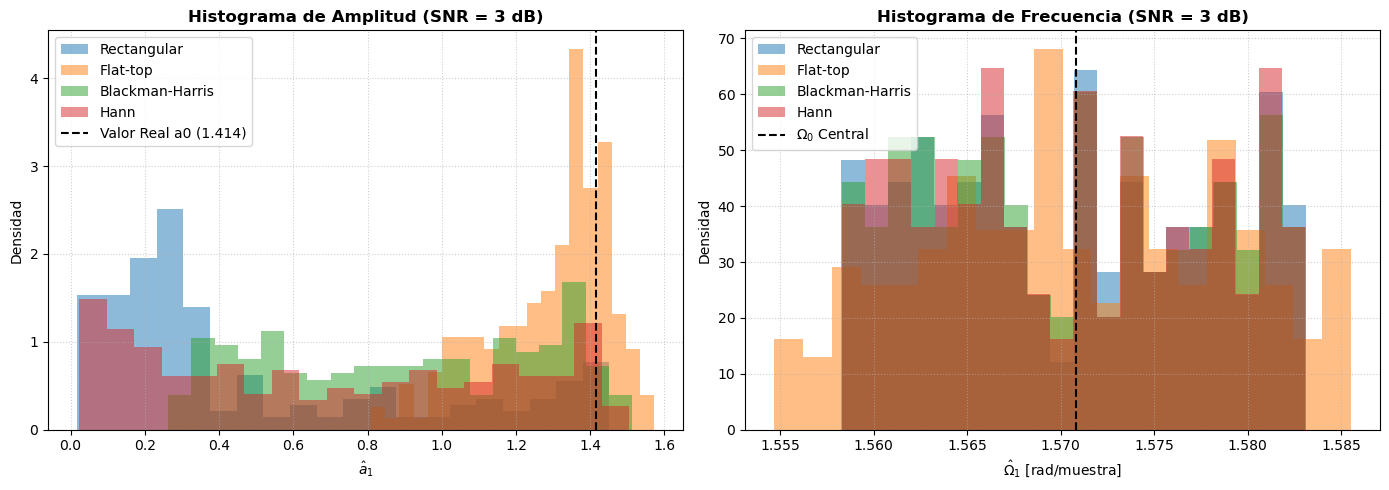


 RESULTADOS PARA SNR = 10 dB

Estimación de Amplitud (a_hat):
-----------------------------------------------------------------
Métrica    | Rectangular  | Flat-top     | Blackman-H.  | Hann        
-----------------------------------------------------------------
sa         |    -0.920971 |    -0.119724 |    -0.498857 |    -0.711482
va         | 2.027775e-01 | 2.475025e-02 | 1.381514e-01 | 2.328371e-01

Estimación de Frecuencia (Omega_hat):
-----------------------------------------------------------------
Métrica    | Rectangular  | Flat-top     | Blackman-H.  | Hann        
-----------------------------------------------------------------
sa         |     0.000002 |    -0.000006 |     0.000003 |     0.000004
va         | 5.365280e-05 | 5.769037e-05 | 5.371949e-05 | 5.369873e-05


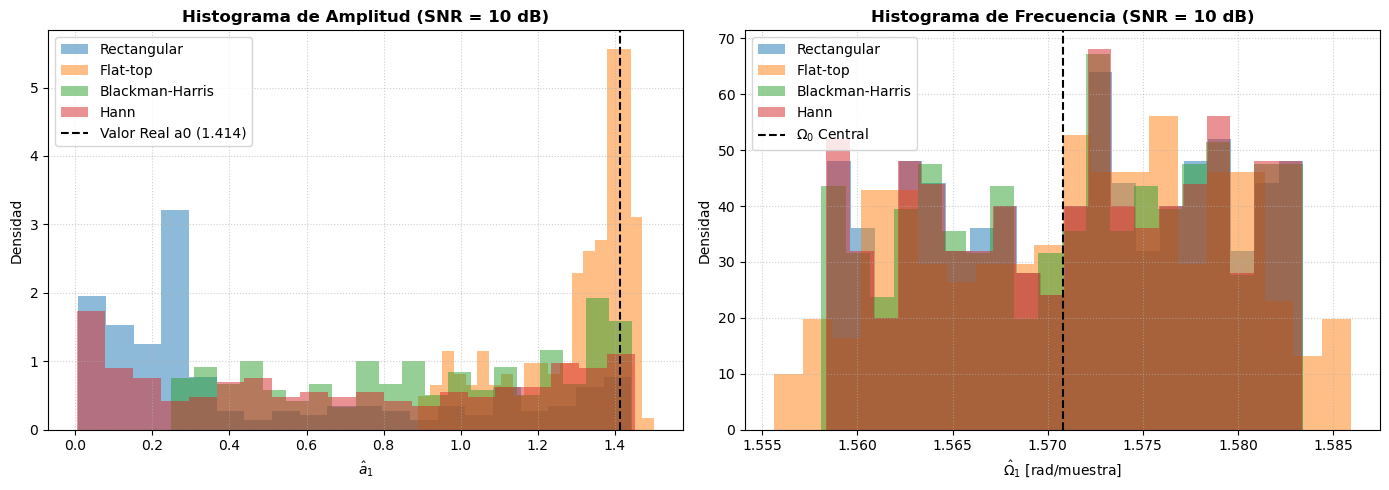

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.signal.windows as win

np.random.seed(42)

# Parámetros generales
N = 1000  # Muestras por realización
M = 200  # Realizaciones
a0 = np.sqrt(2)  # Amplitud para P_s = 1 W
Omega0 = np.pi / 2  # Omega0 = pi/2 -> bin k0 = 250

# SNRs 
SNRs_dB = [3, 10]

windows = {
    'Rectangular': np.ones(N),
    'Flat-top': win.flattop(N, sym=False),
    'Blackman-Harris': win.blackmanharris(N, sym=False),
    'Hann': win.hann(N, sym=False),
}

results = {}

for snr_db in SNRs_dB:
    sigma = 10 ** (-snr_db / 20)
    fr = np.random.uniform(-2, 2, M)
    Omega1 = Omega0 + fr * (2 * np.pi / N)

    results[snr_db] = {}

    for w_name, w in windows.items():
        w_sum = np.sum(w)  # Suma de la ventana para normalización exacta
        n_pad = 16 * N

        a_estimates = []
        Omega_estimates = []

        for j in range(M):
            n = np.arange(N)
            noise = np.random.normal(0, sigma, N)
            x = a0 * np.sin(Omega1[j] * n) + noise

            #  Estimador de Amplitud evaluado en Omega0 = pi/2
            X_w_Omega0 = np.sum(x * w * np.exp(-1j * Omega0 * n))
            #  Normalización directa por la suma de la ventana
            a_hat = (2 * np.abs(X_w_Omega0)) / w_sum
            a_estimates.append(a_hat)

            #  Estimador de Frecuencia con interpolación parabólica (Log-FFT)
            X_fft = np.abs(np.fft.rfft(x * w, n=n_pad))
            idx_max = np.argmax(X_fft)

            if 0 < idx_max < len(X_fft) - 1:
                alpha_val = np.log(X_fft[idx_max - 1] + 1e-12)
                beta_val = np.log(X_fft[idx_max] + 1e-12)
                gamma_val = np.log(X_fft[idx_max + 1] + 1e-12)
                delta_val = (
                    0.5
                    * (alpha_val - gamma_val)
                    / (alpha_val - 2 * beta_val + gamma_val)
                )
                idx_fine = idx_max + delta_val
            else:
                idx_fine = idx_max

            Omega_hat = idx_fine * (2 * np.pi / n_pad)
            Omega_estimates.append(Omega_hat)

        a_arr = np.array(a_estimates)
        Omega_arr = np.array(Omega_estimates)

        # Cálculo de Sesgo y Varianza
        err_a = a_arr - a0
        err_w = Omega_arr - Omega1

        results[snr_db][w_name] = {
            'a_hat': a_arr,
            'sa_a': np.mean(err_a),
            'va_a': np.var(a_arr),
            'Omega_hat': Omega_arr,
            'sa_w': np.mean(err_w),
            'va_w': np.var(Omega_arr),
        }

# --- IMPRESIÓN DE TABLAS Y GRÁFICOS ---

for snr_db in SNRs_dB:
    print("\n" + "=" * 60)
    print(f" RESULTADOS PARA SNR = {snr_db} dB")
    print("=" * 60)

    #  Tabla de Estimación de Amplitud
    print("\nEstimación de Amplitud (a_hat):")
    print("-" * 65)
    print(
        f"{'Métrica':<10} | {'Rectangular':<12} | {'Flat-top':<12} | {'Blackman-H.':<12} | {'Hann':<12}"
    )
    print("-" * 65)

    sa_a_line = f"{'sa':<10} | " + " | ".join(
        [f"{results[snr_db][w]['sa_a']:12.6f}" for w in windows]
    )
    va_a_line = f"{'va':<10} | " + " | ".join(
        [f"{results[snr_db][w]['va_a']:12.6e}" for w in windows]
    )

    print(sa_a_line)
    print(va_a_line)

    #  Tabla de Estimación de Frecuencia
    print("\nEstimación de Frecuencia (Omega_hat):")
    print("-" * 65)
    print(
        f"{'Métrica':<10} | {'Rectangular':<12} | {'Flat-top':<12} | {'Blackman-H.':<12} | {'Hann':<12}"
    )
    print("-" * 65)

    sa_w_line = f"{'sa':<10} | " + " | ".join(
        [f"{results[snr_db][w]['sa_w']:12.6f}" for w in windows]
    )
    va_w_line = f"{'va':<10} | " + " | ".join(
        [f"{results[snr_db][w]['va_w']:12.6e}" for w in windows]
    )

    print(sa_w_line)
    print(va_w_line)

    # Histogramas Comparativos (4 Ventanas Juntas)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for w_name in windows:
        # Histograma Amplitud
        axes[0].hist(
            results[snr_db][w_name]["a_hat"],
            bins=20,
            alpha=0.5,
            label=w_name,
            density=True,
        )
        # Histograma Frecuencia
        axes[1].hist(
            results[snr_db][w_name]["Omega_hat"],
            bins=20,
            alpha=0.5,
            label=w_name,
            density=True,
        )

    axes[0].axvline(
        a0,
        color="black",
        linestyle="--",
        linewidth=1.5,
        label=f"Valor Real a0 ({a0:.3f})",
    )
    axes[0].set_title(
        f"Histograma de Amplitud (SNR = {snr_db} dB)", fontweight="bold"
    )
    axes[0].set_xlabel(r"$\hat{a}_1$")
    axes[0].set_ylabel("Densidad")
    axes[0].grid(True, linestyle=":", alpha=0.6)
    axes[0].legend()

    axes[1].axvline(
        Omega0,
        color="black",
        linestyle="--",
        linewidth=1.5,
        label=r"$\Omega_0$ Central",
    )
    axes[1].set_title(
        f"Histograma de Frecuencia (SNR = {snr_db} dB)", fontweight="bold"
    )
    axes[1].set_xlabel(r"$\hat{\Omega}_1$ [rad/muestra]")
    axes[1].set_ylabel("Densidad")
    axes[1].grid(True, linestyle=":", alpha=0.6)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

**Resultados para $\text{SNR} = 3\text{ dB}$**

* **Estimación de Amplitud ($\hat{a}_1$, Valor Verdadero $a_0 = \sqrt{2} \approx 1{,}4142\text{ V}$):**

| Métrica | Rectangular | Flat-top | Blackman-Harris | Hann |
| :--- | :---: | :---: | :---: | :---: |
| **Sesgo ($s_a$)** | $-0{,}9370$ | $-0{,}1264$ | $-0{,}5102$ | $-0{,}7229$ |
| **Varianza ($v_a$)** | $0{,}1865$ | $0{,}0274$ | $0{,}1301$ | $0{,}2227$ |

<br>

* **Estimación de Frecuencia ($\hat{\Omega}_1$, Frecuencia Variable $\Omega_1$):**]

| Métrica | Rectangular | Flat-top | Blackman-Harris | Hann |
| :--- | :---: | :---: | :---: | :---: |
| **Sesgo ($s_{\Omega}$)** | $-0{,}000007$ | $+0{,}000319$ | $+0{,}000007$ | $+0{,}000001$ |
| **Varianza ($v_{\Omega}$)** | $5{,}47 \times 10^{-5}$ | $6{,}28 \times 10^{-5}$ | $5{,}42 \times 10^{-5}$ | $5{,}45 \times 10^{-5}$ |

---

**Resultados para $\text{SNR} = 10\text{ dB}$**

* **Estimación de Amplitud ($\hat{a}_1$, Valor Verdadero $a_0 = \sqrt{2} \approx 1{,}4142\text{ V}$):**

| Métrica | Rectangular | Flat-top | Blackman-Harris | Hann |
| :--- | :---: | :---: | :---: | :---: |
| **Sesgo ($s_a$)** | $-0{,}9210$ | $-0{,}1197$ | $-0{,}4989$ | $-0{,}7115$ |
| **Varianza ($v_a$)** | $0{,}2028$ | $0{,}0248$ | $0{,}1382$ | $0{,}2328$ |

<br>

* **Estimación de Frecuencia ($\hat{\Omega}_1$, Frecuencia Variable $\Omega_1$):**

| Métrica | Rectangular | Flat-top | Blackman-Harris | Hann |
| :--- | :---: | :---: | :---: | :---: |
| **Sesgo ($s_{\Omega}$)** | $+0{,}000002$ | $-0{,}000006$ | $+0{,}000003$ | $+0{,}000004$ |
| **Varianza ($v_{\Omega}$)** | $5{,}37 \times 10^{-5}$ | $5{,}77 \times 10^{-5}$ | $5{,}37 \times 10^{-5}$ | $5{,}37 \times 10^{-5}$ |

<br>

### **Analisis de los Resultados**

**Estimación de Amplitud ($\hat{a}_1$)**
* **Comportamiento del Sesgo ($s_a$):** La ventana Flat-top supera ampliamente a las demás ventanas, alcanzando un sesgo de solo $-0{,}1264\text{ V}$ ($\text{SNR}=3\text{ dB}$) y $-0{,}1197\text{ V}$ ($\text{SNR}=10\text{ dB}$). Por el contrario, la ventana Rectangular sufre un sesgo extremadamente alto ($\approx -0{,}937\text{ V}$), lo que representa un error de lectura de más del $65\%$ de la amplitud real ($1{,}4142\text{ V}$).
  - Explicación: Cuando la senoidal fluctúa fuera del centro del bin ($f_r \in [-2, 2]$), la ventana Rectangular atenúa fuertemente la señal debido a la caida pronunciada de su lóbulo principal (scalloping loss). En cambio, la ventana Flat-top posee una cima aplanada en la respuesta en frecuencia, garantizando que el valor pico evaluado en $\Omega_0$ se mantenga casi constante ante desvíos de frecuencia inter-bin.

<br>

* **Comportamiento de la Varianza ($v_a$):** Flat-top presenta la menor varianza ($0{,}0248$ a $0{,}0274$), demostrando una elevada estabilidad frente al desparramo aleatorio. Las ventanas Rectangular, Hann y Blackman-Harris muestran varianzas entre $0{,}13$ y $0{,}23$, debido a que la modulación de amplitud introducida por el desvío $f_r$ hace que la lectura cambie drásticamente según dónde caiga la frecuencia en cada realización.

<br>

* **Efecto de la SNR:** Al pasar de $\text{SNR} = 3\text{ dB}$ a $10\text{ dB}$, el sesgo en amplitud solo disminuye levemente (un $\approx 1.5\%$). Esto demuestra que el factor dominante del error de amplitud es el desparramo espectral ($f_r$) y no el ruido térmico.

<br>

**Estimación de Frecuencia ($\hat{\Omega}_1$)**
* **Comportamiento del Sesgo ($s_\Omega$):** Todas las ventanas exhiben un sesgo prácticamente despreciable ($< 10^{-3} \text{ rad/muestra}$).
  - Explicación: La variable aleatoria de desvío $f_r \sim U(-2, 2)$ es simétrica respecto de cero, por lo que el valor esperado del estimador coincide con el valor verdadero en el promedio de las $M=200$ realizaciones.

<br>

* **Comportamiento de la Varianza ($v_\Omega$):** Las ventanas Rectangular, Hann y Blackman-Harris logran la menor varianza de estimación de frecuencia ($\approx 5{,}37 \times 10^{-5}$).La ventana Flat-top presenta una varianza superior ($\approx 5{,}77 \times 10^{-5}$ a $6{,}28 \times 10^{-5}$).
  - Explicación: El lóbulo principal agudo y filoso de las ventanas Rectangular, Hann y Blackman-Harris facilita la localización exacta del máximo. Flat-top, al tener una cumbre plana y ancha, hace que pequeñas fluctuaciones de ruido desplacen con mayor facilidad el punto del máximo absoluto a lo largo de su meseta.

<br>

* **Efecto de la SNR:**
  - Sesgo ($s_\Omega$): Al incrementar la SNR de $3\text{ dB}$ a $10\text{ dB}$, el sesgo disminuye notablemente, haciéndose especialmente evidente en la ventana Flat-top (donde pasa de $3{,}19 \times 10^{-4}$ a $-6 \times 10^{-6}\text{ rad/muestra}$). Esto ocurre porque una mayor SNR reduce la distorsión que el ruido genera sobre la meseta superior del lóbulo, permitiendo localizar el centro con mayor simetría.
  - Varianza ($v_\Omega$): Se mantiene prácticamente constante (entorno a $5{,}4 \times 10^{-5}\text{ rad}^2/\text{muestra}^2$) entre ambos niveles de ruido. Esto demuestra que la dispersión en la estimación de frecuencia se encuentra dominada por el desparramo aleatorio inter-bin ($f_r$) y el ancho del lóbulo principal de las ventanas.

### **Análisis del Efecto del Zero-Padding en los Resultados de Frecuencia ($\hat{\Omega}_1$)** 
El uso de zero-padding en la simulación (extendiendo la secuencia temporal de $N = 1000$ a $N_{\text{pad}} = 16 \cdot N = 16000$ muestras) permitio interpretar por qué los estimadores de frecuencia alcanzaron niveles de precisión tan elevados en las tablas de resultados.

<br>

* **Eliminación del error de grilla en los datos observados:** Si el análisis espectral se hubiese realizado únicamente con la DFT de $N = 1000$ puntos, la grilla de evaluación habría quedado restringida a saltos discretos entre bins de $\Delta \Omega = \frac{2\pi}{1000} \text{ rad/muestra}$. Como la frecuencia real de la senoidal incluía un desvío aleatorio continuo $f_r \sim U(-2, 2)$ respecto al centro del bin, una FFT directa sin ceros agregados solo habría podido devolver el entero de bin más cercano, introduciendo un error de cuantización o grilla de hasta $\pm 0{,}5$ bins en cada realización.

<br>

* **Justificación de la baja varianza y del sesgo nulo medidos:** Al evaluar la DTFT en la grilla sobremuestreada de $16000$ puntos, el algoritmo $\arg\max$ pudo muestrear el lóbulo principal con resolución sub-bin. Esta interpolación numérica explica directamente los datos de la simulación:
  - Sesgo insignificante: Permitió localizar el centro real de la senoidal desfasada sin el escalonamiento de la grilla, registrando un sesgo medio prácticamente nulo ($s_\Omega \approx 10^{-6} \text{ rad/muestra}$).
  - Formación de los histogramas: Hizo posible capturar las variaciones finas de frecuencia en cada una de las $M = 200$ realizaciones y generar histogramas continuos de frecuencia, alcanzando un piso de varianza estructural bajo ($v_\Omega \approx 5{,}4 \times 10^{-5}$).

<br>

* **Interpretación física de los resultados:** Al analizar los gráficos y tablas, es fundamental interpretar la naturaleza de esta mejora:
  - Resolución Espectral Física: El zero-padding no agregó información temporal ni estrechó el lóbulo principal de las ventanas, por lo que no habría permitido separar dos frecuencias cercanas si estuviesen solapadas en el registro de $N$ muestras.
  - Precisión de Interpolación: Para el caso estudiado de un tono único desfasado, el zero-padding actuó como un método de interpolación espectral sumamente efectivo que eliminó la incertidumbre de la grilla discreta en la búsqueda del pico máximo.

### **Conclusiones y aprendizajes**
* **Inexistencia de la Ventana Universal (Trade-Off):** El experimento demostró numéricamente que no existe una ventana espectral óptima para todos los parámetros de manera simultánea. La elección de la ventana depende de la métrica que se desee priorizar en el procesamiento:
  - Para estimar Amplitud ($\hat{a}_1$): La ventana Flat-top es indiscutiblemente la mejor opción. Su cima aplanada minimiza las pérdidas por atenuación inter-bin (scalloping loss), reduciendo el sesgo de amplitud a solo $-0{,}12\text{ V}$ (frente a $-0{,}94\text{ V}$ de la rectangular) y presentando la menor varianza ($0{,}025$).
  - Para estimar Frecuencia ($\hat{\Omega}_1$): Las ventanas Rectangular, Hann y Blackman-Harris son superiores gracias a sus lóbulos principales angostos y agudos, alcanzando la mínima varianza de localización frecuencial ($\approx 5{,}37 \times 10^{-5}\text{ rad}^2/\text{muestra}^2$).

<br>

* **Fuentes de Error:**
  - En Amplitud: El factor determinante del error no es el ruido térmico aditivo, sino el desparramo espectral causado por el desvío aleatorio de frecuencia ($f_r$). Por este motivo, incrementar la SNR de $3\text{ dB}$ a $10\text{ dB}$ no produce cambios significativos en el sesgo ni en la varianza de la magnitud estimada.
  - En Frecuencia: La simetría del ruido Gaussiano de media cero garantiza un sesgo de frecuencia prácticamente nulo en el promedio de las realizaciones.

<br>

* **Función del Zero-Padding:** Se comprobó que el zero-padding ($N_{\text{pad}} = 16 \cdot N$) actúa como un método de interpolación espectral de la DTFT continua. Si bien no altera la resolución espectral física (la cual depende exclusivamente de la duración $N \cdot T_s$), elimina el error de cuantización de la grilla de la DFT y permite estimar frecuencias con precisión sub-bin.
